In [1]:
import os
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")
import sys
import numpy as np
import pandas as pd

import scanpy as sc
import palantir

import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
import PINN
from PINN import reader

# identify detached / weird cells

In [4]:
ad = sc.read_h5ad("data/ery_mk.h5ad")
ad

AnnData object with n_obs × n_vars = 22740 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [31]:
ad.uns['pop']

{'mean': array([   68.71174149,   181.0456594 ,   319.71192389,  1033.80104176,
         1221.63752755,  4388.82149907,  6420.56721147,  2300.67040713,
        18898.77670928]),
 'n_lib': array([4, 6, 4, 4, 4, 2, 4, 4, 4]),
 't': array([  3,   7,  12,  27,  49,  76, 112, 161, 269]),
 'var': array([5.64698791e+01, 2.97828935e+02, 7.21614187e+02, 2.48259499e+04,
        2.60310172e+04, 1.62207978e+04, 4.28322705e+05, 1.26096766e+05,
        3.51421915e+05])}

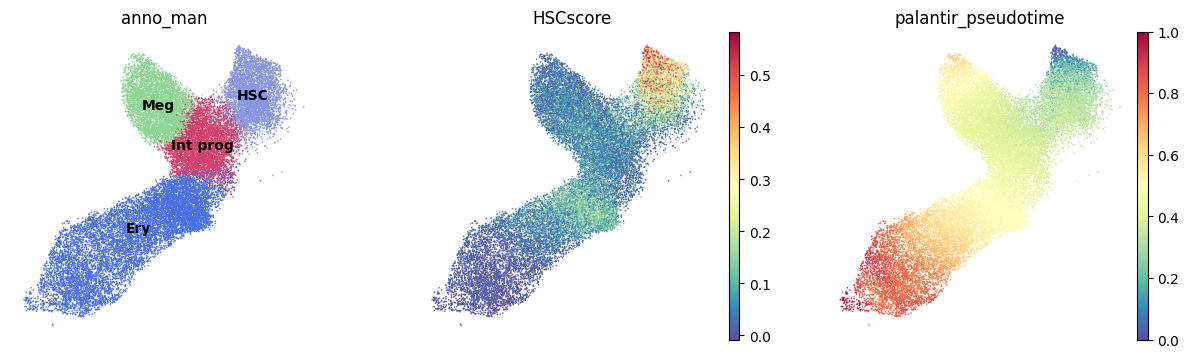

In [13]:
# sc.tl.leiden(ad, resolution=3, key_added='leiden_refined')
sc.pl.umap(ad, color=["anno_man","HSCscore","palantir_pseudotime"], legend_loc='on data', frameon=False)

In [15]:
from tqdm import tqdm

In [16]:
dxs = []
nn_ls = []
for i in tqdm(range(30)):
    dx, nn = PINN.tl.sample_deltax(ad, xkey='DM_EigenVectors_multiscaled', pseudotimekey='palantir_pseudotime', progressbar=False)
    dxs.append(dx)
    nn_ls.append(nn)

100%|██████████| 30/30 [03:27<00:00,  6.91s/it]


In [24]:
np.array(dxs).mean(axis=0).shape

(22740, 8)

In [20]:
np.array(nn_ls)

array([[ 6824,  9122, 20502, ..., 17623,  3690, 17803],
       [21094,  9122, 20502, ..., 17623,  3690, 17803],
       [21094,  9122,  7647, ...,  9680, 19595, 15053],
       ...,
       [21094,  9122,  7825, ..., 17623,  3690,  5334],
       [ 6824, 20781,  7825, ..., 17623,  3690, 22008],
       [21094, 20781, 20502, ..., 17623, 11017, 22008]])

In [22]:
ad.write_h5ad("data/ery_mk.h5ad")

In [25]:
ad.obsm['Delta_DM'].shape

(22740, 8)

In [32]:
import scvelo as scv
cellstate_ad = PINN.tl.make_coord_adata(ad, n_dimension=8, cellstate_key='DM_EigenVectors_multiscaled', v = None)
# vkeys = [k for k in list(cellstate_ad.layers.keys()) if k.endswith("v")]
sc.pp.neighbors(cellstate_ad, n_neighbors=15)


In [40]:
cellstate_ad.layers['velocity'] =  ad.obsm['Delta_DM'].copy()

computing velocity graph (using 20/256 cores)


  0%|          | 0/22740 [00:00<?, ?cells/s]

    finished (0:00:12) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:03) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


ValueError: color key is invalid! pass valid observation annotation or a gene name

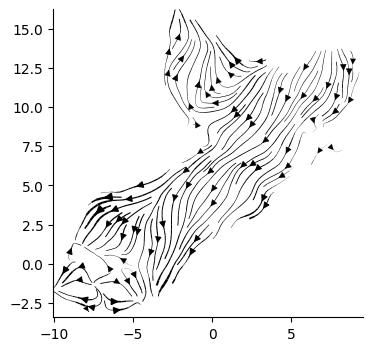

In [ ]:
# # compute velocity graph
# scv.tl.velocity_graph(cellstate_ad, vkey='velocity', xkey='cellstate', n_jobs=20)

# vis
fig_velocity = plt.figure(dpi=100, figsize=(4,4))
ax = fig_velocity.gca()
scv.pl.velocity_embedding_stream(cellstate_ad, color="DM_EigenVectors_multiscaled", 
                                 vkey='velocity', 
                                    basis='umap', ax=ax, 
                                    legend_loc='right', alpha=0.01)

#

# Data spliting

In [5]:
train_test_ratio = [0.8,0.1,0.1]

In [6]:
ad.shape

(22740, 4814)

In [20]:
train_val_cells = np.random.choice(ad.obs_names, size=int(22740*0.9), replace=False)
val_cells = np.random.choice(train_val_cells, size=int(len(train_val_cells)*0.1), replace=False)

In [21]:
train_val_cells.shape

(20466,)

In [22]:
ad.obs['split'] = 'test'
ad.obs.loc[train_val_cells, 'split'] = 'train'
ad.obs.loc[val_cells, 'split'] = 'val'

In [23]:
ad.obs['split'].value_counts()

split
train    18420
test      2274
val       2046
Name: count, dtype: int64

In [24]:
ad.write_h5ad("data/ery_mk.h5ad")